# 🪙 Gold Price Time Series Forecasting — Advanced Analytics & Modeling (1833–2026)

## 0) 🔧 Setup — Theme, Imports, Utilities

In [17]:
# =========================
# 📌 Core
# =========================
import numpy as np
import pandas as pd

# =========================
# 📌 Visualization
# =========================
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import matplotlib.pyplot as plt

# =========================
# 📌 Stats / TS
# =========================
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

# =========================
# 📌 ML
# =========================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, IsolationForest

# Optional: XGBoost (if available)
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# Optional: Prophet (install might be needed on Kaggle env)
HAS_PROPHET = False
try:
    from prophet import Prophet
    HAS_PROPHET = True
except Exception:
    pass

# Optional: pmdarima for auto_arima
HAS_PMDARIMA = False
try:
    import pmdarima as pm
    HAS_PMDARIMA = True
except Exception:
    pass

import warnings
warnings.filterwarnings("ignore")

🎨 Dark + Neon Theme (Plotly global styling)

In [18]:
# Color palette (as requested)
COL_PRICE = "#FFD700"     # gold
COL_TREND = "#00FFFF"     # cyan
COL_FORECAST = "#FF4C4C"  # red
COL_VOL = "#9B59B6"       # purple
COL_MAGENTA = "#FF00FF"
BG = "#0B0F14"
GRID = "rgba(255,255,255,0.08)"
TEXT = "rgba(255,255,255,0.90)"

def apply_dark_theme(fig, title=None, height=520):
    fig.update_layout(
        template="plotly_dark",
        paper_bgcolor=BG,
        plot_bgcolor=BG,
        font=dict(color=TEXT, size=13),
        height=height,
        title=dict(text=title, x=0.01, xanchor="left") if title else None,
        margin=dict(l=60, r=40, t=70, b=50),
        legend=dict(
            bgcolor="rgba(0,0,0,0)",
            bordercolor="rgba(255,255,255,0.12)",
            borderwidth=1
        ),
        xaxis=dict(showgrid=True, gridcolor=GRID, zeroline=False),
        yaxis=dict(showgrid=True, gridcolor=GRID, zeroline=False),
    )
    return fig

def banner(text):
    display_markdown = f"""
---
## {text}
---
"""
    from IPython.display import Markdown, display
    display(Markdown(display_markdown))

## 📊 Step 1: Data Loading & Preprocessing
1.1 Load, parse date, set index, sort

In [19]:
banner("📊 Step 1 — Data Loading & Preprocessing")

df = pd.read_csv("gold_advanced_features.csv")

# Auto-detect date column
date_col = None
for c in df.columns:
    if c.lower() in ["date", "datetime", "time", "timestamp"]:
        date_col = c
        break
if date_col is None:
    # fallback: first column likely date
    date_col = df.columns[0]

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).sort_values(date_col).set_index(date_col)

df.head()


---
## 📊 Step 1 — Data Loading & Preprocessing
---


,price,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,...,roll_std_6,momentum_1,momentum_3,pct_change_1,pct_change_3,ewm_3,ewm_6,price_to_roll3,price_to_roll12,volatility_3
date,,,,,,,,,,,,,,,,,,,,,
1834-01-01,18.93,1834,1,1,0.500000,8.660254e-01,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
1834-02-01,18.93,1834,2,1,0.866025,5.000000e-01,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
1834-03-01,18.93,1834,3,1,1.000000,6.123234e-17,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
1834-04-01,18.93,1834,4,2,0.866025,-5.000000e-01,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0
1834-05-01,18.93,1834,5,2,0.500000,-8.660254e-01,18.93,18.93,18.93,18.93,...,0.0,0.0,0.0,0.0,0.0,18.93,18.93,1.0,1.0,0.0


1.2 Target detection + basic cleaning

In [20]:
# Auto-detect target (prefer Gold_Price)
target_candidates = [c for c in df.columns if c.lower() in ["gold_price", "price", "gold", "close", "value"]]
target = "Gold_Price" if "Gold_Price" in df.columns else (target_candidates[0] if target_candidates else df.columns[0])

# Coerce numeric
df[target] = pd.to_numeric(df[target], errors="coerce")

# Missing values
df = df.sort_index()
df = df.replace([np.inf, -np.inf], np.nan)

# Fill: target by interpolation + ffill for features
df[target] = df[target].interpolate(method="time").ffill().bfill()
feature_cols = [c for c in df.columns if c != target]
df[feature_cols] = df[feature_cols].ffill().bfill()

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2306 entries, 1834-01-01 to 2026-02-01
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            2306 non-null   float64
 1   year             2306 non-null   int64  
 2   month            2306 non-null   int64  
 3   quarter          2306 non-null   int64  
 4   month_sin        2306 non-null   float64
 5   month_cos        2306 non-null   float64
 6   lag_1            2306 non-null   float64
 7   lag_2            2306 non-null   float64
 8   lag_3            2306 non-null   float64
 9   lag_6            2306 non-null   float64
 10  lag_12           2306 non-null   float64
 11  roll_mean_3      2306 non-null   float64
 12  roll_mean_6      2306 non-null   float64
 13  roll_mean_12     2306 non-null   float64
 14  roll_std_3       2306 non-null   float64
 15  roll_std_6       2306 non-null   float64
 16  momentum_1       2306 non-null   float64
 

1.3 Time continuity validation (frequency inference + gap report)

In [21]:
# Infer frequency
inferred_freq = pd.infer_freq(df.index)
print("Inferred frequency:", inferred_freq)

# Gap diagnostics
deltas = df.index.to_series().diff().dropna()
gap_summary = deltas.value_counts().head(10)
gap_summary

Inferred frequency: MS


date
31 days    1345
30 days     768
28 days     145
29 days      47
Name: count, dtype: int64

If you want a uniform grid (recommended for ARIMA/SARIMA), you can resample:

In [ ]:
# Example: force daily (change to 'M' monthly if your data is monthly)
# df = df.resample("D").mean()
# df[target] = df[target].interpolate("time").ffill().bfill()
# df[feature_cols] = df[feature_cols].ffill().bfill()

## 🔍 Step 2: Exploratory Data Analysis (EDA)
2.1 📈 Full historical trend + rolling overlays

In [22]:
banner("🔍 Step 2 — Exploratory Data Analysis (EDA)")

# Rolling windows (adapt if frequency is monthly)
roll_30 = df[target].rolling(30, min_periods=5).mean()
roll_90 = df[target].rolling(90, min_periods=10).mean()
roll_365 = df[target].rolling(365, min_periods=20).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df[target], name="Gold Price", line=dict(color=COL_PRICE, width=2)))
fig.add_trace(go.Scatter(x=df.index, y=roll_30, name="Rolling Mean 30", line=dict(color=COL_TREND, width=1.6)))
fig.add_trace(go.Scatter(x=df.index, y=roll_90, name="Rolling Mean 90", line=dict(color=COL_MAGENTA, width=1.4)))
fig.add_trace(go.Scatter(x=df.index, y=roll_365, name="Rolling Mean 365", line=dict(color=COL_VOL, width=1.4)))
apply_dark_theme(fig, "📈 Gold Price (Raw) + Rolling Means", height=560)
fig.show()


---
## 🔍 Step 2 — Exploratory Data Analysis (EDA)
---


2.2 Log-scale view (long-horizon clarity)

In [23]:
df["log_price"] = np.log(df[target].clip(lower=1e-9))

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df["log_price"], name="Log(Gold Price)", line=dict(color=COL_PRICE, width=2)))
apply_dark_theme(fig, "📈 Log-Transformed Gold Price (Long-Term Readability)", height=520)
fig.show()

2.3 📊 Distribution: histogram + KDE proxy + boxplot + skew/kurtosis

In [24]:
from scipy.stats import skew, kurtosis

sk = skew(df[target].dropna())
ku = kurtosis(df[target].dropna(), fisher=True)

fig = make_subplots(rows=1, cols=2, subplot_titles=("Histogram", "Boxplot"))
fig.add_trace(go.Histogram(x=df[target], nbinsx=80, name="Price Dist", marker_color=COL_PRICE, opacity=0.85), row=1, col=1)
fig.add_trace(go.Box(y=df[target], name="Box", marker_color=COL_TREND), row=1, col=2)
apply_dark_theme(fig, f"📊 Distribution | Skew={sk:.2f}, Kurtosis={ku:.2f}", height=420)
fig.show()

2.4 📅 Seasonality: monthly heatmap (works best when data is daily)

In [25]:
df_seas = df.copy()
df_seas["Year"] = df_seas.index.year
df_seas["Month"] = df_seas.index.month

monthly = df_seas.groupby(["Year", "Month"])[target].mean().reset_index()
pivot = monthly.pivot(index="Year", columns="Month", values=target)

fig = px.imshow(
    pivot,
    aspect="auto",
    color_continuous_scale="Turbo",
    title="📅 Monthly Average Gold Price Heatmap (Year x Month)"
)
apply_dark_theme(fig, height=560)
fig.update_coloraxes(colorbar_title="Avg Price")
fig.show()

2.5 Year-by-year normalized comparison (reveals changing seasonal shape)

In [26]:
# normalize within year (z-score or minmax). We'll use z-score
yearly = df_seas.groupby(["Year", "Month"])[target].mean().reset_index()
yearly["z"] = yearly.groupby("Year")[target].transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))

fig = px.line(yearly, x="Month", y="z", color="Year",
              title="🔄 Within-Year Seasonality Shape (Z-scored by year)")
apply_dark_theme(fig, height=520)
fig.update_traces(opacity=0.30)
fig.show()

## ⚙️ Step 3: Time Series Decomposition (Additive + Multiplicative)


---
## ⚙️ Step 3 — Time Series Decomposition
---


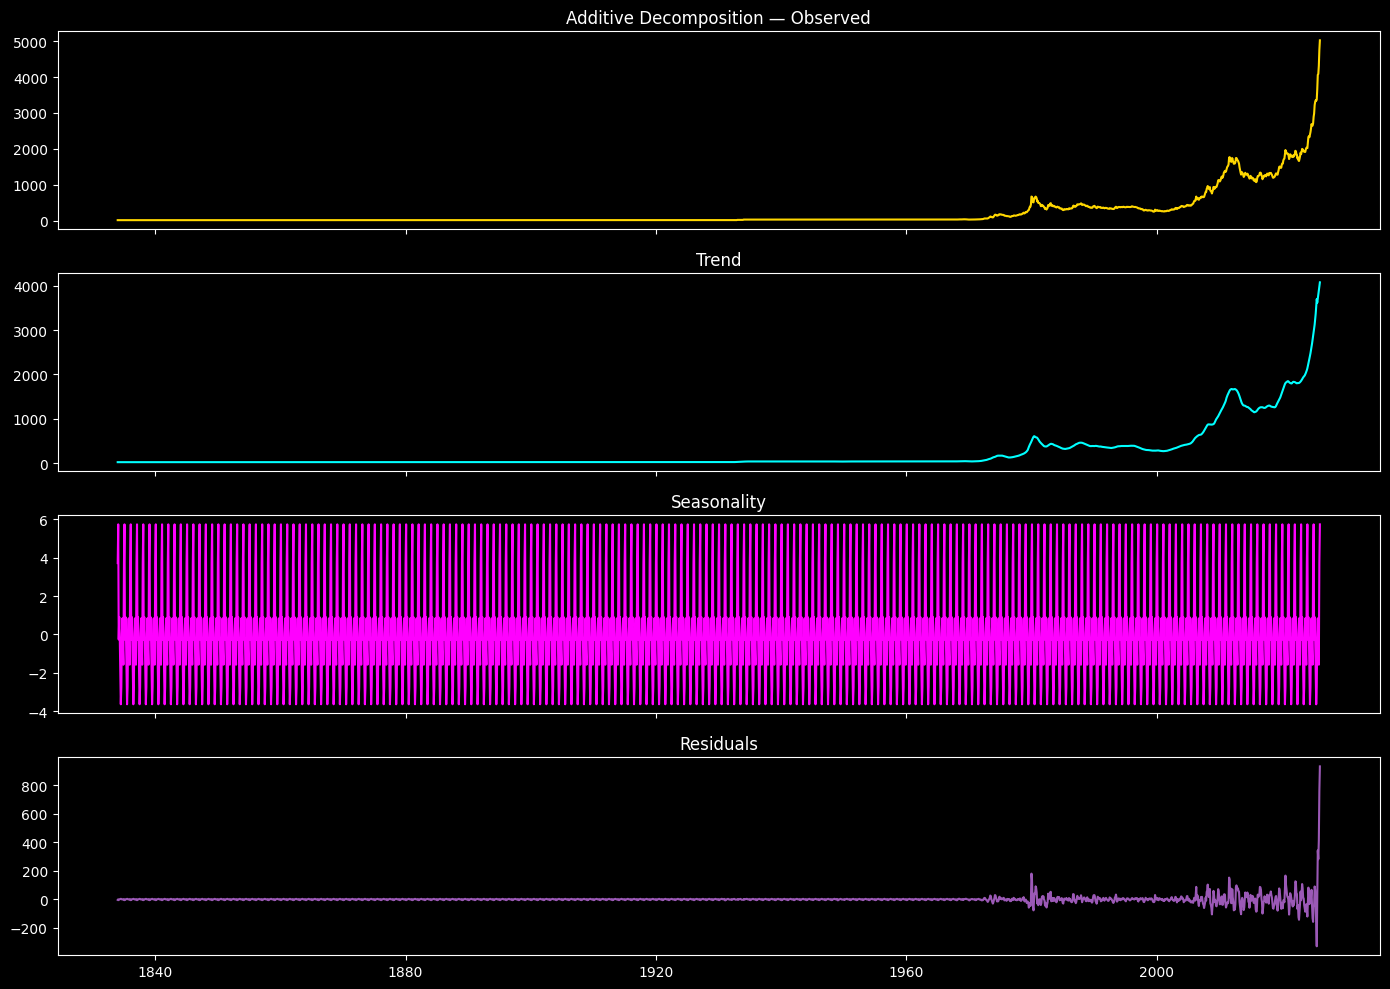

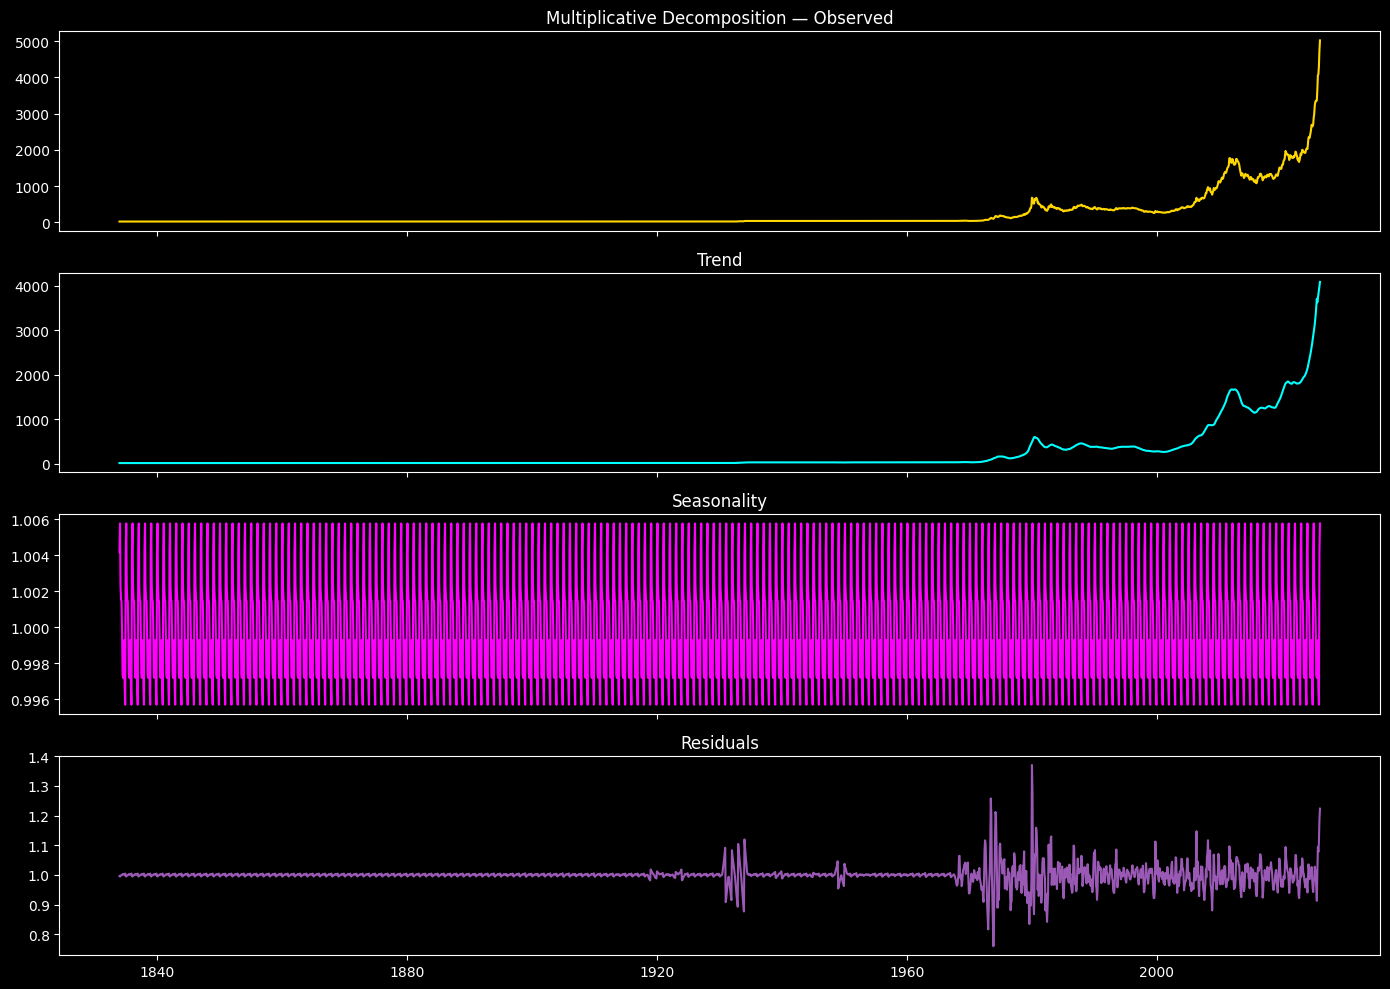

In [27]:
banner("⚙️ Step 3 — Time Series Decomposition")

# Choose period heuristically
period = 12 if (inferred_freq and "M" in inferred_freq) else 365

series = df[target].asfreq(df.index.inferred_freq) if inferred_freq else df[target]

# Fallback: if asfreq creates NaNs
series = series.interpolate("time").ffill().bfill()

add = seasonal_decompose(series, model="additive", period=period, extrapolate_trend="freq")
mul = seasonal_decompose(series.clip(lower=1e-9), model="multiplicative", period=period, extrapolate_trend="freq")

# Matplotlib plots (required in your spec)
plt.style.use("dark_background")
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(add.observed, color=COL_PRICE); axes[0].set_title("Additive Decomposition — Observed")
axes[1].plot(add.trend, color=COL_TREND); axes[1].set_title("Trend")
axes[2].plot(add.seasonal, color=COL_MAGENTA); axes[2].set_title("Seasonality")
axes[3].plot(add.resid, color=COL_VOL); axes[3].set_title("Residuals")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(mul.observed, color=COL_PRICE); axes[0].set_title("Multiplicative Decomposition — Observed")
axes[1].plot(mul.trend, color=COL_TREND); axes[1].set_title("Trend")
axes[2].plot(mul.seasonal, color=COL_MAGENTA); axes[2].set_title("Seasonality")
axes[3].plot(mul.resid, color=COL_VOL); axes[3].set_title("Residuals")
plt.tight_layout()
plt.show()

## 📉 Step 4: Stationarity Check (ADF + KPSS) + Transformations

In [28]:
banner("📉 Step 4 — Stationarity Checks")

def adf_test(x):
    x = x.dropna()
    stat, p, *_ = adfuller(x, autolag="AIC")
    return stat, p

def kpss_test(x):
    x = x.dropna()
    stat, p, *_ = kpss(x, regression="c", nlags="auto")
    return stat, p

x0 = df[target]
xlog = np.log(x0.clip(lower=1e-9))
xd1 = x0.diff()
xlogd1 = xlog.diff()

tests = []
for name, s in [("Raw", x0), ("Log", xlog), ("Diff1", xd1), ("Log+Diff1", xlogd1)]:
    adf_stat, adf_p = adf_test(s)
    kpss_stat, kpss_p = kpss_test(s.dropna())
    tests.append([name, adf_stat, adf_p, kpss_stat, kpss_p])

res = pd.DataFrame(tests, columns=["Series", "ADF stat", "ADF p", "KPSS stat", "KPSS p"])
res


---
## 📉 Step 4 — Stationarity Checks
---


,Series,ADF stat,ADF p,KPSS stat,KPSS p
0,Raw,3.479776,1.000000e+00,3.465478,0.01
1,Log,2.158498,9.988466e-01,5.984546,0.01
2,Diff1,5.947787,1.000000e+00,0.908013,0.01
3,Log+Diff1,-7.818671,6.761750e-12,1.066954,0.01


Before vs After visualization

In [29]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=("Raw", "Log + Diff(1)"))
fig.add_trace(go.Scatter(x=df.index, y=x0, name="Raw", line=dict(color=COL_PRICE)), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=xlogd1, name="LogDiff1", line=dict(color=COL_TREND)), row=2, col=1)
apply_dark_theme(fig, "📉 Stationarity Transform View", height=620)
fig.show()

## 🔗 Step 5: Correlation & Feature Engineering Signal Checks
5.1 Correlation heatmap (top features only)

In [30]:
banner("🔗 Step 5 — Correlations & Feature Signals")

# Select numeric cols and limit size
num = df.select_dtypes(include=[np.number]).copy()

# If too many engineered columns, pick top by correlation magnitude vs target
corr = num.corr(numeric_only=True)[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
top_features = corr.head(25).index.tolist()

heat = num[[target] + top_features].corr()

fig = px.imshow(heat, color_continuous_scale="RdBu", zmin=-1, zmax=1, title="🧊 Correlation Heatmap (Target + Top Features)")
apply_dark_theme(fig, height=720)
fig.show()


---
## 🔗 Step 5 — Correlations & Feature Signals
---


5.2 Lag impact plot (if you have Lag_* columns)

In [31]:
lag_cols = [c for c in df.columns if c.lower().startswith("lag")]
if lag_cols:
    lag_corr = df[lag_cols].corrwith(df[target]).sort_index()
    fig = px.bar(lag_corr, title="⏪ Lag Feature Correlation with Target", color_discrete_sequence=[COL_TREND])
    apply_dark_theme(fig, height=460)
    fig.show()

5.3 Feature importance via Random Forest (fast, strong baseline)

In [32]:
# Basic supervised framing: predict next-step price (t+1)
y = df[target].shift(-1)
X = df.drop(columns=[target]).copy()

# Keep numeric only
X = X.select_dtypes(include=[np.number]).copy()

# Align
data = X.join(y.rename("y")).dropna()
X2, y2 = data.drop(columns=["y"]), data["y"]

# Time-based split (last 20% as test)
split = int(len(data) * 0.8)
X_train, X_test = X2.iloc[:split], X2.iloc[split:]
y_train, y_test = y2.iloc[:split], y2.iloc[split:]

rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(30)

fig = px.bar(imp[::-1], orientation="h", title="🧠 Random Forest Feature Importance (Predict Next Step)",
             color_discrete_sequence=[COL_MAGENTA])
apply_dark_theme(fig, height=820)
fig.show()

## 📊 Step 6: Volatility & Risk Analysis (Returns, Rolling Vol, Drawdowns)

In [33]:
banner("⚠️ Step 6 — Volatility & Risk Analysis")

df["ret"] = df[target].pct_change()
df["log_ret"] = np.log(df[target]).diff()

# Rolling volatility (choose window based on freq)
vol_window = 30 if (not inferred_freq or "D" in str(inferred_freq)) else 6
df["roll_vol"] = df["log_ret"].rolling(vol_window).std() * np.sqrt(vol_window)

# Drawdown
df["cum_max"] = df[target].cummax()
df["drawdown"] = df[target] / df["cum_max"] - 1.0

# Plot price + volatility + drawdown
fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=("Gold Price", f"Rolling Volatility (window={vol_window})", "Drawdown"))
fig.add_trace(go.Scatter(x=df.index, y=df[target], name="Price", line=dict(color=COL_PRICE, width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["roll_vol"], name="Volatility", line=dict(color=COL_VOL, width=1.6)), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["drawdown"], name="Drawdown", line=dict(color=COL_FORECAST, width=1.6)), row=3, col=1)
apply_dark_theme(fig, "⚠️ Risk Dashboard — Price, Volatility, Drawdown", height=820)
fig.update_yaxes(tickformat=".0%", row=3, col=1)
fig.show()


---
## ⚠️ Step 6 — Volatility & Risk Analysis
---


Volatility clustering (autocorrelation of squared returns)

<Figure size 1400x400 with 0 Axes>

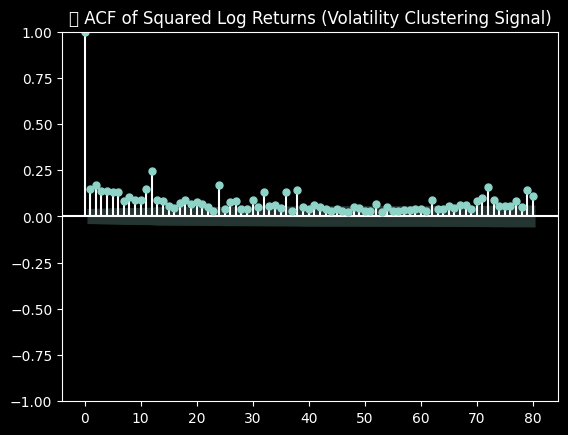

In [34]:
plt.figure(figsize=(14,4))
plt.style.use("dark_background")
plot_acf(df["log_ret"].dropna()**2, lags=80)
plt.title("📌 ACF of Squared Log Returns (Volatility Clustering Signal)")
plt.show()

## 🤖 Step 7: Modeling & Forecasting
We’ll build multiple models and compare.

Shared helpers (metrics + plotting)

In [36]:
banner("🤖 Step 7 — Modeling & Forecasting")

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

def plot_actual_vs_pred(index, y_true, y_pred, title):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=index, y=y_true, name="Actual", line=dict(color=COL_PRICE, width=2)))
    fig.add_trace(go.Scatter(x=index, y=y_pred, name="Predicted", line=dict(color=COL_TREND, width=2)))
    apply_dark_theme(fig, title, height=520)
    fig.show()


---
## 🤖 Step 7 — Modeling & Forecasting
---


7.1 Classical: ARIMA / SARIMA (auto tuning if available)

In [37]:
results = []

# Prepare series (regular frequency helps)
s = df[target].copy()
if inferred_freq:
    s = s.asfreq(inferred_freq).interpolate("time").ffill().bfill()

split = int(len(s) * 0.85)
train_s, test_s = s.iloc[:split], s.iloc[split:]

if HAS_PMDARIMA:
    model = pm.auto_arima(
        train_s,
        seasonal=True,
        m=12 if ("M" in str(inferred_freq)) else 7,  # heuristic; adjust if needed
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False
    )
    fc = model.predict(n_periods=len(test_s))
    pred = pd.Series(fc, index=test_s.index)

    results.append(["Auto(ARIMA/SARIMA)", mean_absolute_error(test_s, pred), rmse(test_s, pred), mape(test_s, pred)])
    plot_actual_vs_pred(test_s.index, test_s, pred, "📈 Auto ARIMA/SARIMA — Actual vs Pred (Holdout)")
else:
    print("pmdarima not available. Skipping auto_arima. (You can pip install pmdarima).")

7.2 Prophet (trend + seasonality; great storytelling model)

In [ ]:
if HAS_PROPHET:
    # Prophet expects columns: ds, y
    proph = df[[target]].reset_index().rename(columns={df.index.name or "index":"ds", target:"y"})
    proph["ds"] = pd.to_datetime(proph["ds"])
    
    split = int(len(proph) * 0.85)
    train_p, test_p = proph.iloc[:split], proph.iloc[split:]

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    m.fit(train_p)

    future = m.make_future_dataframe(periods=len(test_p), freq=inferred_freq if inferred_freq else "D")
    forecast = m.predict(future)
    pred = forecast.set_index("ds")["yhat"].iloc[-len(test_p):]
    actual = test_p.set_index("ds")["y"]

    results.append(["Prophet", mean_absolute_error(actual, pred), rmse(actual, pred), mape(actual, pred)])

    plot_actual_vs_pred(actual.index, actual, pred, "🔮 Prophet — Actual vs Pred (Holdout)")
else:
    print("Prophet not available. Skipping. (You can pip install prophet).")

7.3 Machine Learning: Random Forest & XGBoost (supervised next-step regression)

In [ ]:
# Dataset
y = df[target].shift(-1)
X = df.drop(columns=[target]).select_dtypes(include=[np.number]).copy()
data = X.join(y.rename("y")).dropna()

split = int(len(data) * 0.85)
X_train, X_test = data.drop(columns=["y"]).iloc[:split], data.drop(columns=["y"]).iloc[split:]
y_train, y_test = data["y"].iloc[:split], data["y"].iloc[split:]

# RF
rf = RandomForestRegressor(n_estimators=800, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = pd.Series(rf.predict(X_test), index=y_test.index)

results.append(["RandomForest (t+1)", mean_absolute_error(y_test, pred_rf), rmse(y_test, pred_rf), mape(y_test, pred_rf)])
plot_actual_vs_pred(y_test.index, y_test, pred_rf, "🌲 Random Forest — Next-Step Prediction (Holdout)")

# XGB
if HAS_XGB:
    xgb = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    )
    xgb.fit(X_train, y_train)
    pred_xgb = pd.Series(xgb.predict(X_test), index=y_test.index)

    results.append(["XGBoost (t+1)", mean_absolute_error(y_test, pred_xgb), rmse(y_test, pred_xgb), mape(y_test, pred_xgb)])
    plot_actual_vs_pred(y_test.index, y_test, pred_xgb, "⚡ XGBoost — Next-Step Prediction (Holdout)")
else:
    print("XGBoost not available. Skipping.")

## 📊 Step 8: Model Evaluation (MAE/RMSE/MAPE comparison table)

In [ ]:
banner("📊 Step 8 — Model Evaluation")

score = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "MAPE (%)"]).sort_values("RMSE")
score

In [ ]:
fig = px.bar(
    score.sort_values("RMSE"),
    x="RMSE",
    y="Model",
    orientation="h",
    title="🏁 Model Leaderboard (Lower RMSE is Better)",
    color="RMSE",
    color_continuous_scale="Turbo"
)
apply_dark_theme(fig, height=480)
fig.show()

## 🔮 Step 9: Future Forecast (12–24 months)

In [ ]:
banner("🔮 Step 9 — Future Forecast (12–24 months)")

horizon = 365 if (not inferred_freq or "D" in str(inferred_freq)) else 24  # ~12-24 months depending on freq

if HAS_PROPHET:
    proph = df[[target]].reset_index().rename(columns={df.index.name or "index":"ds", target:"y"})
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    m.fit(proph)

    future = m.make_future_dataframe(periods=horizon, freq=inferred_freq if inferred_freq else "D")
    fc = m.predict(future).set_index("ds")

    # Plot with CI
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df.index, y=df[target], name="Historical", line=dict(color=COL_PRICE, width=2)))
    fig.add_trace(go.Scatter(x=fc.index, y=fc["yhat"], name="Forecast", line=dict(color=COL_FORECAST, width=2)))

    fig.add_trace(go.Scatter(
        x=fc.index, y=fc["yhat_upper"], name="Upper CI",
        line=dict(color="rgba(255,76,76,0.25)"), showlegend=False
    ))
    fig.add_trace(go.Scatter(
        x=fc.index, y=fc["yhat_lower"], name="Lower CI",
        line=dict(color="rgba(255,76,76,0.25)"), fill="tonexty", fillcolor="rgba(255,76,76,0.12)",
        showlegend=False
    ))
    apply_dark_theme(fig, "🔮 Prophet Forecast + Confidence Interval", height=560)
    fig.show()

elif HAS_PMDARIMA:
    s = df[target].copy()
    if inferred_freq:
        s = s.asfreq(inferred_freq).interpolate("time").ffill().bfill()

    model = pm.auto_arima(s, seasonal=True, m=12 if ("M" in str(inferred_freq)) else 7,
                          stepwise=True, suppress_warnings=True)
    fc, conf = model.predict(n_periods=horizon, return_conf_int=True)
    future_idx = pd.date_range(start=s.index[-1], periods=horizon+1, freq=inferred_freq if inferred_freq else "D")[1:]
    fc = pd.Series(fc, index=future_idx)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=s.index, y=s, name="Historical", line=dict(color=COL_PRICE, width=2)))
    fig.add_trace(go.Scatter(x=fc.index, y=fc, name="Forecast", line=dict(color=COL_FORECAST, width=2)))

    fig.add_trace(go.Scatter(x=future_idx, y=conf[:, 1], line=dict(color="rgba(255,76,76,0.2)"), showlegend=False))
    fig.add_trace(go.Scatter(x=future_idx, y=conf[:, 0], line=dict(color="rgba(255,76,76,0.2)"),
                             fill="tonexty", fillcolor="rgba(255,76,76,0.12)", showlegend=False))
    apply_dark_theme(fig, "🔮 Auto ARIMA/SARIMA Forecast + Confidence Interval", height=560)
    fig.show()

else:
    print("No Prophet/ARIMA tooling available. Install prophet or pmdarima for true future forecasting.")

## 📌 Step 10: Insights & Business Interpretation (Educational)

In [ ]:
banner("📌 Step 10 — Insights & Business Interpretation (Educational)")

# Example: identify worst drawdowns + highest vol periods
worst_dd = df["drawdown"].min()
worst_dd_date = df["drawdown"].idxmin()

high_vol = df["roll_vol"].quantile(0.99)
high_vol_periods = df[df["roll_vol"] >= high_vol].index[:10]

summary = pd.DataFrame({
    "Metric": ["Worst drawdown", "Worst drawdown date", "99th pct rolling vol", "Example high-vol dates (first 10)"],
    "Value": [f"{worst_dd:.2%}", str(worst_dd_date.date()), f"{high_vol:.4f}", ", ".join([d.strftime("%Y-%m-%d") for d in high_vol_periods])]
})
summary

## 🧠 Bonus (Standout Add-ons)
A) 🚨 Anomaly Detection (Isolation Forest)

In [ ]:
banner("🚨 Bonus — Anomaly Detection (Isolation Forest)")

feat = df.select_dtypes(include=[np.number]).copy()
feat = feat.dropna()
iso = IsolationForest(n_estimators=400, contamination=0.01, random_state=42)
anom = iso.fit_predict(feat)

df_anom = df.loc[feat.index].copy()
df_anom["anomaly"] = (anom == -1)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_anom.index, y=df_anom[target], name="Price", line=dict(color=COL_PRICE, width=2)))
fig.add_trace(go.Scatter(
    x=df_anom.index[df_anom["anomaly"]],
    y=df_anom.loc[df_anom["anomaly"], target],
    mode="markers", name="Anomaly",
    marker=dict(color=COL_FORECAST, size=7, symbol="x")
))
apply_dark_theme(fig, "🚨 Price Anomalies Detected (Isolation Forest)", height=520)
fig.show()

B) 🧭 Regime Change Detection (fast proxy: rolling volatility + trend slope)

In [ ]:
banner("🧭 Bonus — Regime/Phase Detection (Volatility + Trend Slope Proxy)")

# Trend slope proxy
w = 180 if (not inferred_freq or "D" in str(inferred_freq)) else 12
trend_proxy = df[target].rolling(w).mean()
slope = trend_proxy.diff(w)

reg = pd.DataFrame({
    "price": df[target],
    "vol": df["roll_vol"],
    "slope": slope
}).dropna()

# Simple regime classification
reg["regime"] = "Neutral"
reg.loc[(reg["vol"] > reg["vol"].quantile(0.75)) & (reg["slope"] > 0), "regime"] = "High-Vol Uptrend"
reg.loc[(reg["vol"] > reg["vol"].quantile(0.75)) & (reg["slope"] < 0), "regime"] = "High-Vol Downtrend"
reg.loc[(reg["vol"] <= reg["vol"].quantile(0.75)) & (reg["slope"] > 0), "regime"] = "Low-Vol Uptrend"
reg.loc[(reg["vol"] <= reg["vol"].quantile(0.75)) & (reg["slope"] < 0), "regime"] = "Low-Vol Downtrend"

fig = px.scatter(
    reg.reset_index(),
    x="slope", y="vol", color="regime",
    hover_data=[reg.reset_index().columns[0], "price"],
    title="🧭 Regime Map (Slope vs Volatility)"
)
apply_dark_theme(fig, height=520)
fig.show()

C) 🎛️ Interactive time-range slider (for presentation polish)

In [ ]:
banner("🎛️ Bonus — Interactive Time Filtering")

fig = px.line(df.reset_index(), x=df.index.name or "Date", y=target, title="🎛️ Gold Price with Range Slider")
fig.update_traces(line=dict(color=COL_PRICE, width=2))
apply_dark_theme(fig, height=520)
fig.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
fig.show()